# 04 Explainability (XAI) & Site Data Export
**ADHD EEG Classification Project**

**Goals:**
- Compute SHAP values for the Random Forest model
- Generate topographic brain maps (MNE) showing feature importance spatially
- Export a single `site_data.json` containing all numbers the React site needs

**Input:** `features.csv` (from notebook 02) + pre-run CV results (re-run here for export)

**Outputs:**
- `plots/09_shap_summary.png`  global SHAP summary (beeswarm)
- `plots/10_shap_waterfall_adhd.png`  SHAP waterfall for one ADHD subject
- `plots/10_shap_waterfall_control.png`  SHAP waterfall for one Control subject
- `plots/11_topomap_theta.png`  topographic map of mean Theta power (ADHD vs Control)
- `plots/11_topomap_tbr.png`  topographic map of mean Theta/Beta ratio
- `plots/11_topomap_shap.png`  topographic map of SHAP importance per channel
- `site_data.json`  all structured data for the React frontend

## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import mne
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
os.makedirs('plots', exist_ok=True)

RANDOM_STATE = 42
CHANNELS = ['Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2',
            'F7','F8','T7','T8','P7','P8','Fz','Cz','Pz']
BANDS = {'Delta': (1,4), 'Theta': (4,8), 'Alpha': (8,12), 'Beta': (12,30)}
COLORS = {'ADHD': '#e07b7b', 'Control': '#7bb8e0'}

print('Imports OK')

Imports OK


## 1. Load Feature Matrix & Re-run CV for Export

We re-run CV here so we can capture exact numeric results for `site_data.json`.

In [2]:
df = pd.read_csv('features.csv')
meta_cols = ['label', 'subject']
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].values
y = (df['label'] == 'ADHD').astype(int).values
subjects = df['subject'].values
labels = df['label'].values

print(f'Feature matrix : {X.shape}')
print(f'ADHD=1: {y.sum()}  |  Control=0: {(y==0).sum()}')

Feature matrix : (121, 171)
ADHD=1: 61  |  Control=0: 60


In [3]:
rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel='rbf', C=10, gamma='scale',
        probability=True, random_state=RANDOM_STATE
    ))
])

models = {'Random Forest': rf, 'SVM (RBF)': svm}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'f1', 'roc_auc']

cv_results_export = {}
oof_probs = {}   # out-of-fold probabilities for ROC export
oof_preds = {}   # out-of-fold predictions for confusion matrix export

for name, model in models.items():
    print(f'Running CV for {name}...')
    res = cross_validate(model, X, y, cv=cv, scoring=scoring)
    cv_results_export[name] = {
        'accuracy_mean': float(res['test_accuracy'].mean()),
        'accuracy_std':  float(res['test_accuracy'].std()),
        'f1_mean':       float(res['test_f1'].mean()),
        'f1_std':        float(res['test_f1'].std()),
        'roc_auc_mean':  float(res['test_roc_auc'].mean()),
        'roc_auc_std':   float(res['test_roc_auc'].std()),
    }

    # Collect out-of-fold predictions
    y_prob = np.zeros(len(y))
    y_pred = np.zeros(len(y), dtype=int)
    for train_idx, test_idx in cv.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        y_prob[test_idx] = model.predict_proba(X[test_idx])[:, 1]
        y_pred[test_idx] = model.predict(X[test_idx])
    oof_probs[name] = y_prob
    oof_preds[name] = y_pred

    print(f"  Accuracy: {cv_results_export[name]['accuracy_mean']:.3f} "
          f"± {cv_results_export[name]['accuracy_std']:.3f}")
    print(f"  ROC-AUC : {cv_results_export[name]['roc_auc_mean']:.3f} "
          f"± {cv_results_export[name]['roc_auc_std']:.3f}")
    print()

Running CV for Random Forest...
  Accuracy: 0.686 ± 0.042
  ROC-AUC : 0.754 ± 0.048

Running CV for SVM (RBF)...
  Accuracy: 0.654 ± 0.062
  ROC-AUC : 0.683 ± 0.085



## 2. ROC Curve Data Export

Compute FPR/TPR arrays for both models These get stored in `site_data.json`  
so Plotly.js can render the ROC curves interactively on the site.

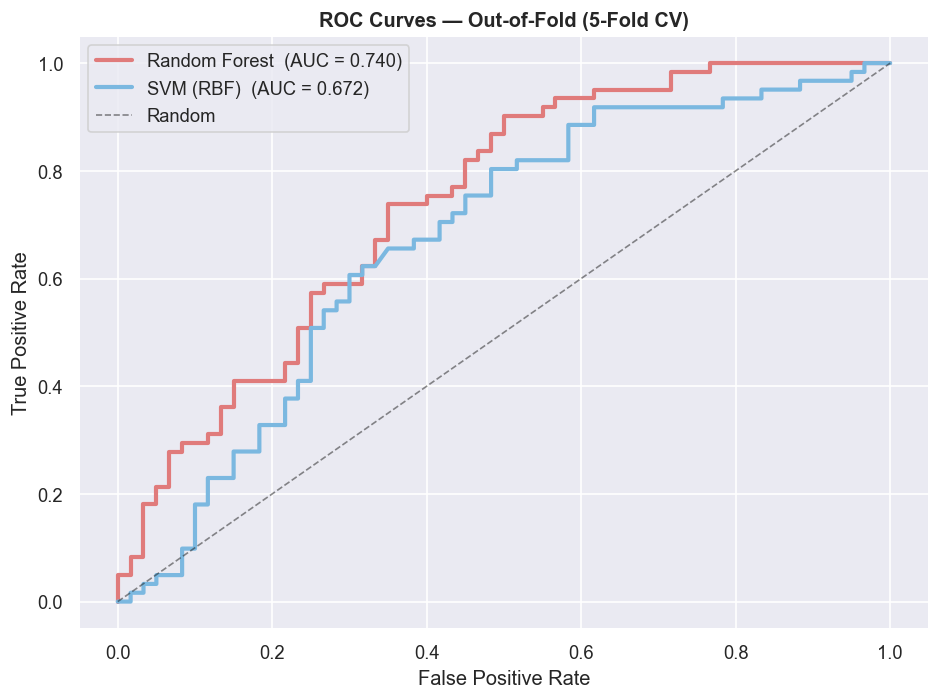

ROC data ready for export.


In [4]:
roc_data_export = {}

fig, ax = plt.subplots(figsize=(8, 6))
model_plot_colors = {'Random Forest': '#e07b7b', 'SVM (RBF)': '#7bb8e0'}

for name in models:
    fpr, tpr, thresholds = roc_curve(y, oof_probs[name])
    auc = roc_auc_score(y, oof_probs[name])

    # Downsample to ~100 points for JSON size
    step = max(1, len(fpr) // 100)
    roc_data_export[name] = {
        'fpr': fpr[::step].tolist(),
        'tpr': tpr[::step].tolist(),
        'auc': round(auc, 4)
    }

    ax.plot(fpr, tpr, color=model_plot_colors[name], linewidth=2.5,
            label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Out-of-Fold (5-Fold CV)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plots/07b_roc_combined.png', bbox_inches='tight')
plt.show()

print('ROC data ready for export.')

## 3. Confusion Matrix Export

In [5]:
cm_export = {}

for name in models:
    cm = confusion_matrix(y, oof_preds[name])
    # cm layout: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    cm_export[name] = {
        'TN': int(tn), 'FP': int(fp),
        'FN': int(fn), 'TP': int(tp),
        'matrix': cm.tolist()  # [[TN,FP],[FN,TP]]
    }
    print(f'{name}: TN={tn} FP={fp} FN={fn} TP={tp}')

Random Forest: TN=38 FP=22 FN=16 TP=45
SVM (RBF): TN=40 FP=20 FN=22 TP=39


## 4. Feature Importance Export (Random Forest)

Fit RF on the full dataset for stable importance estimates, then export top 20.

In [6]:
rf.fit(X, y)
importances = rf.named_steps['clf'].feature_importances_

df_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

top20 = df_imp.head(20)

def feature_type(name):
    if name.startswith('TBR'):   return 'Theta/Beta Ratio'
    if name.startswith('Delta'): return 'Delta'
    if name.startswith('Theta'): return 'Theta'
    if name.startswith('Alpha'): return 'Alpha'
    if name.startswith('Beta'):  return 'Beta'
    return 'Statistical'

feature_importance_export = [
    {
        'feature': row['feature'],
        'importance': round(float(row['importance']), 6),
        'type': feature_type(row['feature'])
    }
    for _, row in top20.iterrows()
]

print('Top 10 features:')
for f in feature_importance_export[:10]:
    print(f"  {f['feature']:20s}  {f['importance']:.5f}  [{f['type']}]")

Top 10 features:
  Var_P7                0.04010  [Statistical]
  Var_P3                0.02351  [Statistical]
  TBR_Pz                0.02142  [Theta/Beta Ratio]
  Alpha_Cz              0.02139  [Alpha]
  Var_T7                0.01808  [Statistical]
  Var_Pz                0.01776  [Statistical]
  Beta_Cz               0.01734  [Beta]
  Beta_F4               0.01574  [Beta]
  Var_F7                0.01488  [Statistical]
  Var_O2                0.01486  [Statistical]


## 5. SHAP Values

We use `shap.TreeExplainer`, fast and exact for Random Forest.  
We export:
- Global mean |SHAP| per feature (top 20) → for the summary bar chart on the site
- Full SHAP matrix → for the beeswarm plot image
- Per-subject SHAP values for one ADHD and one Control example → for waterfall charts

In [7]:
# SHAP on the RF fitted in section 4 (full dataset)
# Note: TreeExplainer works on the raw classifier, not the Pipeline
# We need to pass scaled X since the scaler is inside the pipeline

X_scaled = rf.named_steps['scaler'].transform(X)
explainer = shap.TreeExplainer(rf.named_steps['clf'])
shap_values = explainer.shap_values(X_scaled)

# shap_values is a list of 2 arrays (one per class) for RF
# shap_values[1] = SHAP for class ADHD=1
sv = np.array(shap_values)
shap_adhd = sv[:, :, 1]  # shape: (121, 171)
print(f'shap_adhd shape: {shap_adhd.shape}')

print(f'Expected value (base rate): {explainer.expected_value[1]:.4f}')

shap_adhd shape: (121, 171)
Expected value (base rate): 0.5040


In [8]:
# Global mean |SHAP| per feature — top 20
mean_abs_shap = np.abs(shap_adhd).mean(axis=0)
df_shap = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

shap_summary_export = [
    {
        'feature': row['feature'],
        'mean_abs_shap': round(float(row['mean_abs_shap']), 6),
        'type': feature_type(row['feature'])
    }
    for _, row in df_shap.head(20).iterrows()
]

print('Top 10 features by mean |SHAP|:')
for f in shap_summary_export[:10]:
    print(f"  {f['feature']:20s}  {f['mean_abs_shap']:.5f}")

Top 10 features by mean |SHAP|:
  Var_P7                0.03050
  Var_P3                0.01385
  Var_Pz                0.01295
  Alpha_Cz              0.01241
  Var_O2                0.01241
  Var_T7                0.01199
  TBR_Pz                0.01076
  Beta_F4               0.00957
  Var_F7                0.00951
  Beta_Cz               0.00941


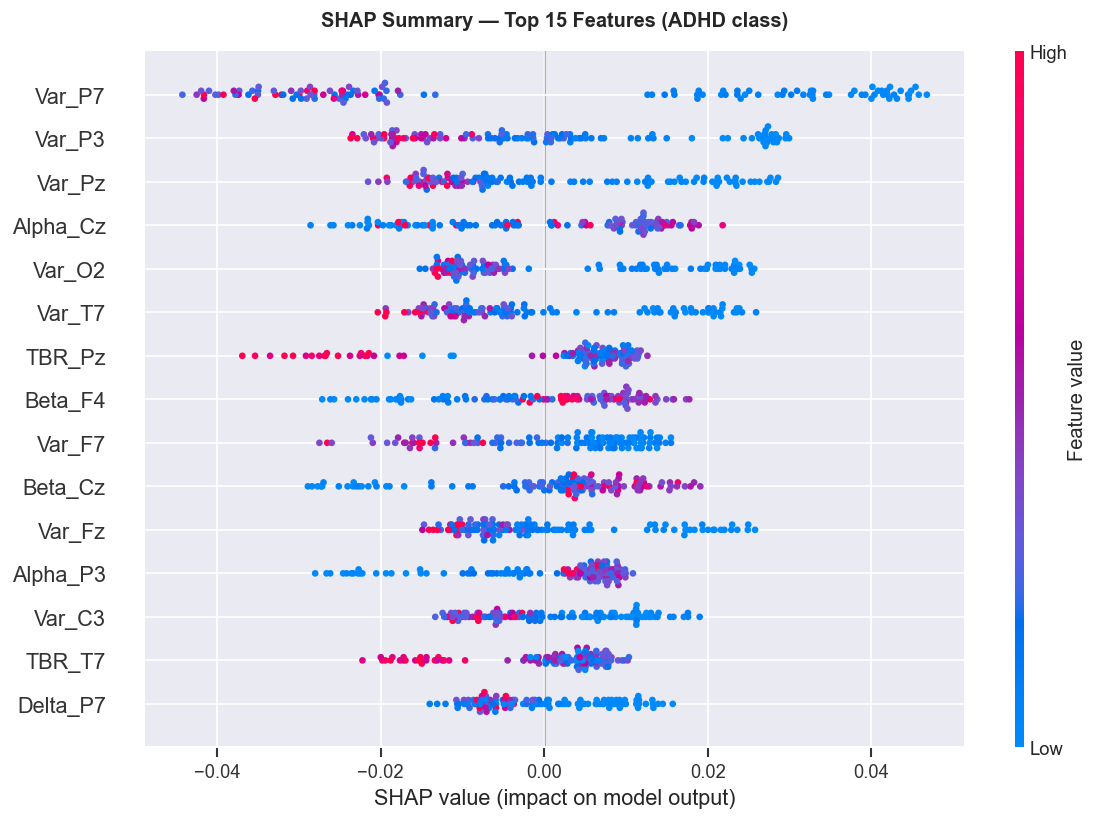

Saved: plots/09_shap_summary.png


In [9]:
# SHAP beeswarm plot -global summary
# We show top 15 features for clarity

top15_features = df_shap.head(15)['feature'].tolist()
top15_idx = [feature_cols.index(f) for f in top15_features]

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_adhd[:, top15_idx],
    X_scaled[:, top15_idx],
    feature_names=top15_features,
    show=False,
    plot_size=(10, 7)
)
plt.title('SHAP Summary — Top 15 Features (ADHD class)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plots/09_shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: plots/09_shap_summary.png')

In [10]:
# SHAP waterfall plots, one ADHD subject, one Control subject
# Pick the subject whose prediction probability is closest to the group mean
# (more representative than picking a random one)

adhd_mask    = y == 1
control_mask = y == 0

# Predicted probabilities from the full-fit RF
probs_full = rf.predict_proba(X)[:, 1]

# Most representative ADHD subject: closest to mean ADHD probability
adhd_mean_prob = probs_full[adhd_mask].mean()
adhd_rep_idx   = np.where(adhd_mask)[0][
    np.argmin(np.abs(probs_full[adhd_mask] - adhd_mean_prob))
]

# Most representative Control subject
ctrl_mean_prob = probs_full[control_mask].mean()
ctrl_rep_idx   = np.where(control_mask)[0][
    np.argmin(np.abs(probs_full[control_mask] - ctrl_mean_prob))
]

print(f'Representative ADHD subject index   : {adhd_rep_idx}  (p={probs_full[adhd_rep_idx]:.3f})')
print(f'Representative Control subject index: {ctrl_rep_idx}  (p={probs_full[ctrl_rep_idx]:.3f})')

Representative ADHD subject index   : 11  (p=0.812)
Representative Control subject index: 120  (p=0.183)


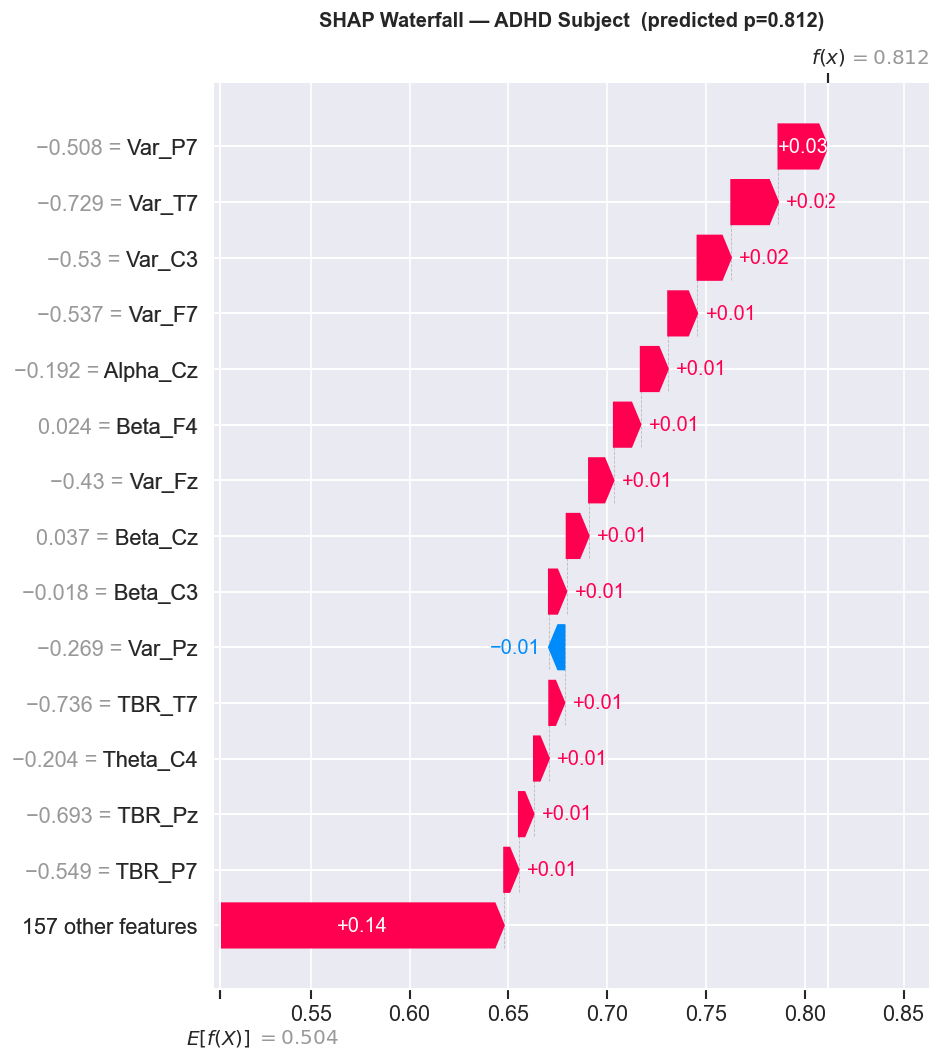

Saved: plots/10_shap_waterfall_adhd.png


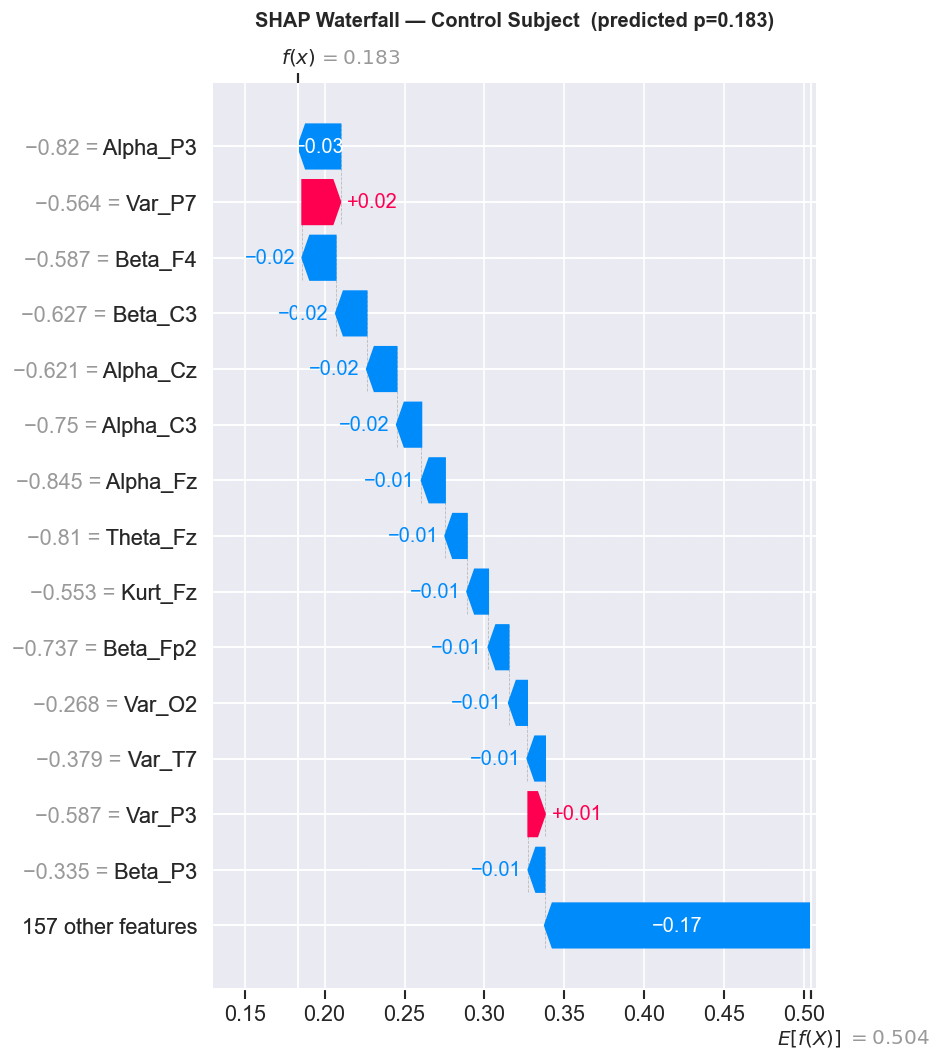

Saved: plots/10_shap_waterfall_control.png


In [11]:
# Waterfall for ADHD subject
# shap.plots.waterfall needs an Explanation object
base_value = explainer.expected_value[1]

for idx, label_str, fname in [
    (adhd_rep_idx, 'ADHD',    'plots/10_shap_waterfall_adhd.png'),
    (ctrl_rep_idx, 'Control', 'plots/10_shap_waterfall_control.png')
]:
    explanation = shap.Explanation(
        values=shap_adhd[idx],
        base_values=base_value,
        data=X_scaled[idx],
        feature_names=feature_cols
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — {label_str} Subject  '
              f'(predicted p={probs_full[idx]:.3f})',
              fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved: {fname}')

In [12]:
# Export SHAP waterfall data for Plotly.js on the site
# We take the top 15 features by |SHAP| for each subject

def waterfall_export(subject_idx, label_str):
    sv = shap_adhd[subject_idx]
    top_idx = np.argsort(np.abs(sv))[::-1][:15]
    return {
        'label': label_str,
        'predicted_prob': round(float(probs_full[subject_idx]), 4),
        'base_value': round(float(base_value), 4),
        'features': [
            {
                'feature': feature_cols[i],
                'shap_value': round(float(sv[i]), 6),
                'feature_value': round(float(X_scaled[subject_idx][i]), 4),
                'type': feature_type(feature_cols[i])
            }
            for i in top_idx
        ]
    }

shap_waterfall_export = {
    'ADHD':    waterfall_export(adhd_rep_idx, 'ADHD'),
    'Control': waterfall_export(ctrl_rep_idx, 'Control')
}

print('Waterfall data ready.')
print(f"ADHD top feature    : {shap_waterfall_export['ADHD']['features'][0]['feature']}")
print(f"Control top feature : {shap_waterfall_export['Control']['features'][0]['feature']}")

Waterfall data ready.
ADHD top feature    : Var_P7
Control top feature : Alpha_P3


## 6. Topographic Brain Maps (MNE)

Three topomaps:
1. Mean Theta power - ADHD vs Control side by side
2. Mean Theta/Beta Ratio - ADHD vs Control side by side  
3. Mean |SHAP| per channel - which channels drive classification most

MNE uses standard 10-20 electrode positions for our 19 channels.

In [13]:
# Set up MNE info object with standard 10-20 positions
info = mne.create_info(
    ch_names=CHANNELS,
    sfreq=128,
    ch_types='eeg'
)
info.set_montage('standard_1020')
print('MNE montage set.')
print(f'Channels: {CHANNELS}')

MNE montage set.
Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']


In [14]:
# Get per-channel mean band power for ADHD and Control groups
# We use df (features.csv) which has columns like 'Theta_Fp1', 'Theta_Fp2', etc.

def get_channel_values(band_prefix, group_label):
    """Return array of shape (19,) — mean band power per channel for a group."""
    group = df[df['label'] == group_label]
    cols  = [f'{band_prefix}_{ch}' for ch in CHANNELS]
    return group[cols].mean().values

theta_adhd    = get_channel_values('Theta', 'ADHD')
theta_ctrl    = get_channel_values('Theta', 'Control')
tbr_adhd      = get_channel_values('TBR',   'ADHD')
tbr_ctrl      = get_channel_values('TBR',   'Control')

print('Band power per channel ready.')
print(f'Theta ADHD mean across channels: {theta_adhd.mean():.4f}')
print(f'Theta Control mean across channels: {theta_ctrl.mean():.4f}')

Band power per channel ready.
Theta ADHD mean across channels: 5454.4216
Theta Control mean across channels: 6690.2033


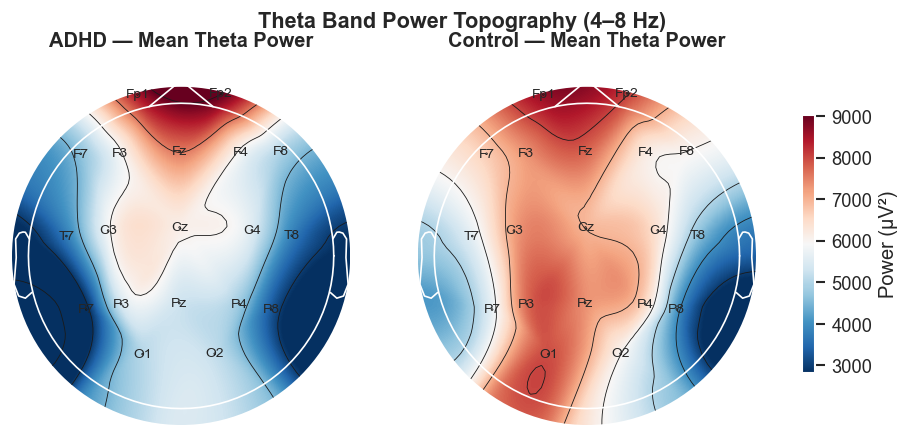

Saved: plots/11_topomap_theta.png


In [15]:
# Topomap 1: Theta power - ADHD vs Control
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

vmin = min(theta_adhd.min(), theta_ctrl.min())
vmax = max(theta_adhd.max(), theta_ctrl.max())

for ax, values, title in [
    (axes[0], theta_adhd, 'ADHD — Mean Theta Power'),
    (axes[1], theta_ctrl, 'Control — Mean Theta Power')
]:
    im, _ = mne.viz.plot_topomap(
        values, info, axes=ax, show=False,
        vlim=(vmin, vmax), cmap='RdBu_r',
        names=CHANNELS
    )
    ax.set_title(title, fontweight='bold', pad=10)

plt.colorbar(im, ax=axes, shrink=0.7, label='Power (µV²)')
plt.suptitle('Theta Band Power Topography (4–8 Hz)', fontsize=13, fontweight='bold')
plt.savefig('plots/11_topomap_theta.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: plots/11_topomap_theta.png')

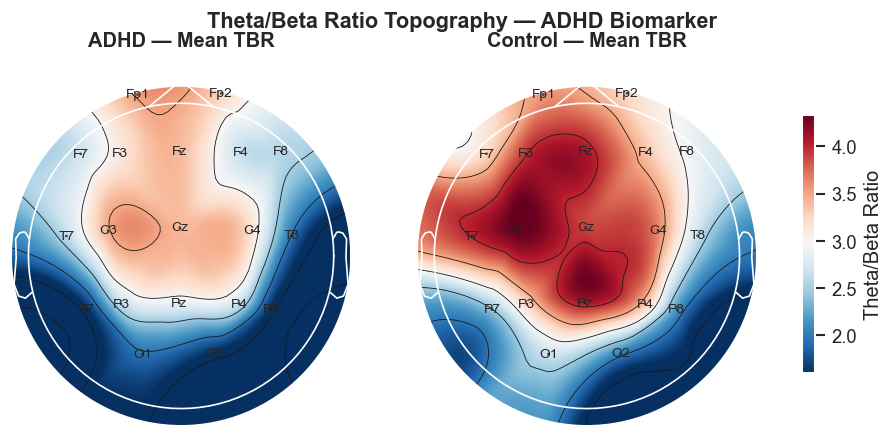

Saved: plots/11_topomap_tbr.png


In [16]:
# Topomap 2: Theta/Beta Ratio - ADHD vs Control
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

vmin = min(tbr_adhd.min(), tbr_ctrl.min())
vmax = max(tbr_adhd.max(), tbr_ctrl.max())

for ax, values, title in [
    (axes[0], tbr_adhd, 'ADHD — Mean TBR'),
    (axes[1], tbr_ctrl, 'Control — Mean TBR')
]:
    im, _ = mne.viz.plot_topomap(
        values, info, axes=ax, show=False,
        vlim=(vmin, vmax), cmap='RdBu_r',
        names=CHANNELS
    )
    ax.set_title(title, fontweight='bold', pad=10)

plt.colorbar(im, ax=axes, shrink=0.7, label='Theta/Beta Ratio')
plt.suptitle('Theta/Beta Ratio Topography — ADHD Biomarker', fontsize=13, fontweight='bold')
plt.savefig('plots/11_topomap_tbr.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: plots/11_topomap_tbr.png')

In [17]:
# Topomap 3: Mean |SHAP| per channel
# Aggregate SHAP importance across all features belonging to each channel

shap_per_channel = np.zeros(len(CHANNELS))
for ch_idx, ch_name in enumerate(CHANNELS):
    # All feature columns that belong to this channel
    ch_feature_idx = [
        i for i, f in enumerate(feature_cols)
        if f.endswith(f'_{ch_name}')
    ]
    if ch_feature_idx:
        shap_per_channel[ch_idx] = np.abs(shap_adhd[:, ch_feature_idx]).mean()

print('Mean |SHAP| per channel:')
for ch, val in zip(CHANNELS, shap_per_channel):
    print(f'  {ch:4s}: {val:.5f}')

Mean |SHAP| per channel:
  Fp1 : 0.00160
  Fp2 : 0.00203
  F3  : 0.00318
  F4  : 0.00296
  C3  : 0.00349
  C4  : 0.00189
  P3  : 0.00397
  P4  : 0.00171
  O1  : 0.00259
  O2  : 0.00285
  F7  : 0.00257
  F8  : 0.00220
  T7  : 0.00317
  T8  : 0.00173
  P7  : 0.00640
  P8  : 0.00207
  Fz  : 0.00362
  Cz  : 0.00432
  Pz  : 0.00470


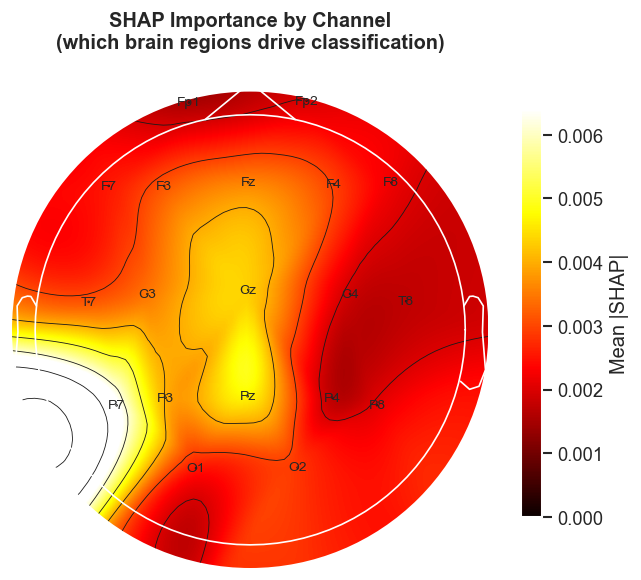

Saved: plots/11_topomap_shap.png


In [18]:
fig, ax = plt.subplots(figsize=(6, 5))

im, _ = mne.viz.plot_topomap(
    shap_per_channel, info, axes=ax, show=False,
    cmap='hot', names=CHANNELS
)
plt.colorbar(im, ax=ax, shrink=0.8, label='Mean |SHAP|')
ax.set_title('SHAP Importance by Channel\n(which brain regions drive classification)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_topomap_shap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: plots/11_topomap_shap.png')

# Export for JSON
shap_channel_export = [
    {'channel': ch, 'mean_abs_shap': round(float(v), 6)}
    for ch, v in zip(CHANNELS, shap_per_channel)
]

## 7. Band Power Summary for Site (all subjects)

Export mean band power per group — used for the band power comparison section of the site.

In [19]:
band_power_export = {}

for group in ['ADHD', 'Control']:
    grp = df[df['label'] == group]
    band_power_export[group] = {}
    for band in list(BANDS.keys()) + ['TBR']:
        prefix = band if band != 'TBR' else 'TBR'
        cols = [f'{prefix}_{ch}' for ch in CHANNELS]
        # Mean across all subjects and channels
        mean_val = grp[cols].values.mean()
        std_val  = grp[cols].values.mean(axis=1).std()  # std across subjects
        band_power_export[group][band] = {
            'mean': round(float(mean_val), 6),
            'std':  round(float(std_val), 6)
        }

print('Band power summary:')
for group in ['ADHD', 'Control']:
    print(f'\n{group}:')
    for band, vals in band_power_export[group].items():
        print(f'  {band:6s}: mean={vals["mean"]:.4f}  std={vals["std"]:.4f}')

Band power summary:

ADHD:
  Delta : mean=21061.9111  std=13030.7495
  Theta : mean=5454.4216  std=2195.5366
  Alpha : mean=2257.6187  std=1183.4044
  Beta  : mean=2334.5932  std=1135.5952
  TBR   : mean=2.6818  std=0.8891

Control:
  Delta : mean=34257.8692  std=38880.3670
  Theta : mean=6690.2033  std=5539.4757
  Alpha : mean=2360.3908  std=2151.0769
  Beta  : mean=2457.5156  std=2622.2588
  TBR   : mean=3.3295  std=1.4274


## 8. Assemble & Export `site_data.json`

Single file that the React frontend loads. Contains everything needed to render all charts.

In [20]:
site_data = {

    # ── Dataset metadata ──────────────────────────────────────────────────
    'dataset': {
        'name':           'IEEE 19-Channel EEG Dataset (Nasrabadi et al., 2020)',
        'total_subjects': 121,
        'adhd_subjects':  61,
        'control_subjects': 60,
        'sampling_rate_hz': 128,
        'n_channels':     19,
        'channels':       CHANNELS,
        'age_range':      '7–12 years',
        'total_features': 171,
        'feature_breakdown': {
            'band_power': 76,   # 4 bands × 19 channels
            'tbr':        19,   # Theta/Beta Ratio × 19 channels
            'statistical': 76   # mean/var/skew/kurt × 19 channels
        }
    },

    # ── Model results ─────────────────────────────────────────────────────
    'model_results': cv_results_export,

    # ── ROC curve data ────────────────────────────────────────────────────
    'roc_curves': roc_data_export,

    # ── Confusion matrices ────────────────────────────────────────────────
    'confusion_matrices': cm_export,

    # ── Feature importance (RF, mean decrease impurity) ───────────────────
    'feature_importance': feature_importance_export,

    # ── SHAP global summary (mean |SHAP| per feature, top 20) ─────────────
    'shap_summary': shap_summary_export,

    # ── SHAP waterfall for individual subjects ─────────────────────────────
    'shap_waterfall': shap_waterfall_export,

    # ── SHAP per channel (for topographic map reference) ──────────────────
    'shap_per_channel': shap_channel_export,

    # ── Band power summary ────────────────────────────────────────────────
    'band_power': band_power_export,

    # ── Frequency bands definition ────────────────────────────────────────
    'frequency_bands': {
        band: {'low': lo, 'high': hi}
        for band, (lo, hi) in BANDS.items()
    },

    # ── Plots manifest (relative paths for React to load) ─────────────────
    'plots': {
        'dataset_overview':         'plots/01_dataset_overview.png',
        'raw_eeg_adhd':             'plots/02_raw_eeg_adhd.png',
        'raw_eeg_control':          'plots/02_raw_eeg_control.png',
        'psd_comparison':           'plots/03_psd_comparison.png',
        'band_power_boxplots':      'plots/04_band_power_boxplots.png',
        'feature_distributions':    'plots/05_feature_distributions.png',
        'correlation_heatmap':      'plots/06_correlation_heatmap.png',
        'confusion_roc':            'plots/07_confusion_roc.png',
        'roc_combined':             'plots/07b_roc_combined.png',
        'feature_importance':       'plots/08_feature_importance.png',
        'shap_summary':             'plots/09_shap_summary.png',
        'shap_waterfall_adhd':      'plots/10_shap_waterfall_adhd.png',
        'shap_waterfall_control':   'plots/10_shap_waterfall_control.png',
        'topomap_theta':            'plots/11_topomap_theta.png',
        'topomap_tbr':              'plots/11_topomap_tbr.png',
        'topomap_shap':             'plots/11_topomap_shap.png',
    }
}

with open('site_data.json', 'w') as f:
    json.dump(site_data, f, indent=2)

print('=' * 50)
print('site_data.json exported successfully.')
print(f'File size: {os.path.getsize("site_data.json") / 1024:.1f} KB')
print('=' * 50)
print('\nKeys exported:')
for key in site_data:
    print(f'  {key}')

site_data.json exported successfully.
File size: 20.4 KB

Keys exported:
  dataset
  model_results
  roc_curves
  confusion_matrices
  feature_importance
  shap_summary
  shap_waterfall
  shap_per_channel
  band_power
  frequency_bands
  plots


## 9. Final Checklist

In [23]:
import pathlib

expected_outputs = [
    'site_data.json',
    'plots/07b_roc_combined.png',
    'plots/09_shap_summary.png',
    'plots/10_shap_waterfall_adhd.png',
    'plots/10_shap_waterfall_control.png',
    'plots/11_topomap_theta.png',
    'plots/11_topomap_tbr.png',
    'plots/11_topomap_shap.png',
]

print('Output checklist:')
all_ok = True
for path in expected_outputs:
    exists = pathlib.Path(path).exists()
    status = 'OK' if exists else 'MISSING'
    if not exists:
        all_ok = False
    print(f'  [{status}]  {path}')

print()
if all_ok:
    print('All outputs generated.')
else:
    print('Some outputs are missing - check for errors above.')

Output checklist:
  [OK]  site_data.json
  [OK]  plots/07b_roc_combined.png
  [OK]  plots/09_shap_summary.png
  [OK]  plots/10_shap_waterfall_adhd.png
  [OK]  plots/10_shap_waterfall_control.png
  [OK]  plots/11_topomap_theta.png
  [OK]  plots/11_topomap_tbr.png
  [OK]  plots/11_topomap_shap.png

All outputs generated.
